# `reproject_to_match`: FK5 Input to Galactic Template

This notebook demonstrates a frame-changing `reproject_to_match` workflow:
- Input image is built in **FK5 (RA/Dec)**.
- A new template is built in **Galactic** coordinates from an FK5 template reference direction.
- Input is reprojected onto that Galactic template.

Validation goals:
1. Output coordinate system matches the Galactic template coordinate system.
2. Source peak world locations are preserved when converting FK5 -> Galactic.
3. RA/Dec equivalents are attached to the output grid and peak RA/Dec are preserved after transformation.

## 1) Imports

In [20]:
import numpy as np
import xarray as xr

from astropy import units as u
from astropy.coordinates import SkyCoord
from xradio.image import make_empty_sky_image

from plotting import generate_astro_plot
from wcs_reproject import build_wcs_from_xradio, reproject_to_match


## 2) Define geometry and sampling

In [21]:
base_n_l = 192
base_n_m = 192
border_pixels = 64
n_l = base_n_l + 2 * border_pixels
n_m = base_n_m + 2 * border_pixels

template_cell_arcsec = 1.5
input_cell_arcsec = 1.4 * template_cell_arcsec

cell_template = np.deg2rad(template_cell_arcsec / 3600.0)
cell_input = np.deg2rad(input_cell_arcsec / 3600.0)

# Input reference-direction offset in input-pixel units.
ref_shift_l = 20.5 * cell_input
ref_shift_m = 20.5 * cell_input

print("template cell arcsec:", float(template_cell_arcsec))
print("input cell arcsec:", float(input_cell_arcsec))
print("input/template pixel-scale ratio:", float(input_cell_arcsec / template_cell_arcsec))

print("border pixels:", int(border_pixels))
print("image size (l,m):", (int(n_l), int(n_m)))


template cell arcsec: 1.5
input cell arcsec: 2.0999999999999996
input/template pixel-scale ratio: 1.3999999999999997
border pixels: 64
image size (l,m): (320, 320)


## 3) Build the Galactic template and the FK5 input

The FK5 input construction here mirrors the setup in
`notebooks/reproject_to_match_minimal_same_frame.ipynb`:
- larger input pixels,
- reference-direction offset of `(20.5, 20.5)` input pixels.

The template is created directly in the Galactic frame, with phase center
set from FK5 `(0, 0)` transformed to Galactic so both grids overlap on-sky.


In [22]:
fk5_template_ref = SkyCoord(0.0 * u.rad, 0.0 * u.rad, frame="fk5")
gal_template_ref = fk5_template_ref.transform_to("galactic")

template_gal = make_empty_sky_image(
    phase_center=[
        float(gal_template_ref.spherical.lon.to_value(u.rad)),
        float(gal_template_ref.spherical.lat.to_value(u.rad)),
    ],
    image_size=[n_l, n_m],
    cell_size=[cell_template, cell_template],
    frequency_coords=np.array([1.4e9]),
    pol_coords=["I"],
    time_coords=np.array([59000.0]),
    direction_reference="galactic",
    projection="SIN",
    spectral_reference="lsrk",
    do_sky_coords=True,
)
input_fk5 = make_empty_sky_image(
    phase_center=[ref_shift_l, ref_shift_m],
    image_size=[n_l, n_m],
    cell_size=[cell_input, cell_input],
    frequency_coords=np.array([1.4e9]),
    pol_coords=["I"],
    time_coords=np.array([59000.0]),
    direction_reference="fk5",
    projection="SIN",
    spectral_reference="lsrk",
    do_sky_coords=True,
)

def ensure_sky_var(ds, *, data_var="SKY", units="Jy/pixel"):
    # Create SKY if absent, preserving dataset coordinate metadata.
    if data_var not in ds.data_vars:
        ds[data_var] = xr.DataArray(
            np.zeros((1, 1, 1, ds.sizes["l"], ds.sizes["m"]), dtype=np.float64),
            dims=("time", "frequency", "polarization", "l", "m"),
            coords={d: ds.coords[d] for d in ("time", "frequency", "polarization", "l", "m")},
        )
    ds[data_var].attrs["units"] = units
    return ds

template_gal = ensure_sky_var(template_gal, data_var="SKY", units="Jy/pixel")
# Template is coordinate-only; intensity values are irrelevant and set to zero.
template_gal["SKY"].data[...] = 0.0

print("FK5 template ref (deg):", (0.0, 0.0))
print(
    "Galactic template ref (deg):",
    (
        float(gal_template_ref.spherical.lon.to_value(u.deg)),
        float(gal_template_ref.spherical.lat.to_value(u.deg)),
    ),
)
print("input_fk5 ref dir")
print(input_fk5.attrs["coordinate_system_info"]["reference_direction"])
print()
print("template ref dir")
print(template_gal.attrs["coordinate_system_info"]["reference_direction"])

input_fk5


FK5 template ref (deg): (0.0, 0.0)
Galactic template ref (deg): (96.33726960808245, -60.188551730962004)
input_fk5 ref dir
{'attrs': {'frame': 'fk5', 'type': 'sky_coord', 'units': 'rad', 'equinox': 'j2000.0'}, 'data': [0.00020871228971765522, 0.00020871228971765522], 'dims': 'sky_dir_label', 'coords': {'sky_dir_label': {'data': ['ra', 'dec'], 'dims': 'sky_dir_label'}}}

template ref dir
{'attrs': {'frame': 'galactic', 'type': 'sky_coord', 'units': 'rad'}, 'data': [1.681402547042506, -1.0504883997122192], 'dims': 'sky_dir_label', 'coords': {'sky_dir_label': {'data': ['lon', 'lat'], 'dims': 'sky_dir_label'}}}


<xarray.Dataset> Size: 2MB
Dimensions:            (time: 1, frequency: 1, polarization: 1, l: 320, m: 320,
                        beam_params_label: 3)
Coordinates:
  * time               (time) float64 8B 5.9e+04
  * frequency          (frequency) float64 8B 1.4e+09
    velocity           (frequency) float64 8B 0.0
  * polarization       (polarization) <U1 4B 'I'
  * l                  (l) float64 3kB 0.001629 0.001619 ... -0.001609 -0.001619
  * m                  (m) float64 3kB -0.001629 -0.001619 ... 0.001609 0.001619
    right_ascension    (l, m) float64 819kB 0.001838 0.001838 ... 6.282 6.282
    declination        (l, m) float64 819kB -0.00142 -0.00141 ... 0.001828
  * beam_params_label  (beam_params_label) <U5 60B 'major' 'minor' 'pa'
Data variables:
    *empty*
Attributes:
    data_groups:             {'base': {}}
    coordinate_system_info:  {'reference_direction': {'attrs': {'frame': 'fk5...
    type:                    image

## 4) Populate FK5 input with two Gaussians and plot input

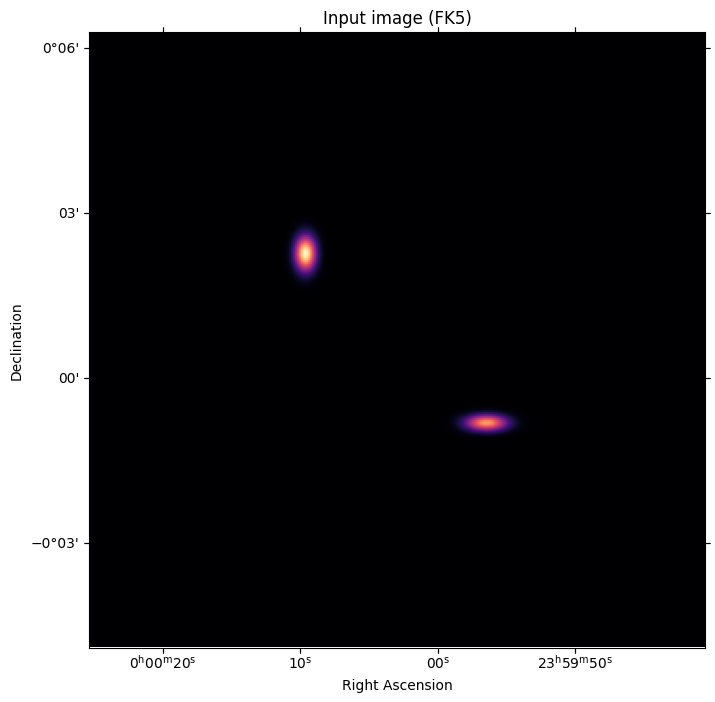

In [23]:
base_input_components = [
    (48.0, 140.0, 3.8, 6.3, 1.0),
    (142.0, 52.0, 7.5, 2.9, 0.8),
]

# Shift source centers with the border so relative geometry is unchanged.
input_components = [
    (ci + border_pixels, cj + border_pixels, si, sj, amp)
    for (ci, cj, si, sj, amp) in base_input_components
]

def gaussian_field_pixel(n_i, n_j, components):
    # Build a 2D sum of elliptical Gaussians in pixel coordinates.
    ii, jj = np.indices((n_i, n_j), dtype=np.float64)
    out = np.zeros((n_i, n_j), dtype=np.float64)
    for i0, j0, sig_i, sig_j, amp in components:
        out += amp * np.exp(-0.5 * (((ii - i0) / sig_i) ** 2 + ((jj - j0) / sig_j) ** 2))
    return out

input_plane = gaussian_field_pixel(n_l, n_m, input_components)

input_fk5 = ensure_sky_var(input_fk5, data_var="SKY", units="Jy/pixel")
input_fk5["SKY"].data[...] = input_plane[None, None, None, :, :]

input_wcs_plot = build_wcs_from_xradio(input_fk5, dim_a="l", dim_b="m").wcs
input_img_plot = input_fk5["SKY"].isel(time=0, frequency=0, polarization=0).values
fig_i, ax_i = generate_astro_plot(input_img_plot, input_wcs_plot)
ax_i.set_title("Input image (FK5)")
ax_i.coords[0].set_axislabel("Right Ascension")
ax_i.coords[1].set_axislabel("Declination")

## 5) Reproject input FK5 image onto Galactic template

In [24]:
out = reproject_to_match(
    input_fk5,
    template_gal,
    data_var="SKY",
    method="bilinear",
    include_original_world_coords=True,
)

print("output SKY shape:", tuple(int(v) for v in out["SKY"].shape))
print(
    "template frame:",
    str(template_gal.attrs["coordinate_system_info"]["reference_direction"]["attrs"].get("frame", "unknown")),
)
print(
    "output frame:",
    str(out.attrs["coordinate_system_info"]["reference_direction"]["attrs"].get("frame", "unknown")),
)
print("has galactic coords:", bool("galactic_longitude" in out.coords and "galactic_latitude" in out.coords))
out

output SKY shape: (1, 1, 1, 320, 320)
template frame: galactic
output frame: galactic
has galactic coords: True


<xarray.Dataset> Size: 4MB
Dimensions:                   (time: 1, frequency: 1, polarization: 1, l: 320,
                               m: 320, beam_params_label: 3)
Coordinates:
  * time                      (time) float64 8B 5.9e+04
  * frequency                 (frequency) float64 8B 1.4e+09
    velocity                  (frequency) float64 8B 0.0
  * polarization              (polarization) <U1 4B 'I'
  * l                         (l) float64 3kB 0.001164 0.001156 ... -0.001156
  * m                         (m) float64 3kB -0.001164 -0.001156 ... 0.001156
    galactic_longitude        (l, m) float64 819kB 1.684 1.684 ... 1.679 1.679
    galactic_latitude         (l, m) float64 819kB -1.052 -1.052 ... -1.049
    original_right_ascension  (l, m) float64 819kB 0.001531 0.001528 ... 6.282
    original_declination      (l, m) float64 819kB -0.0006036 ... 0.0005998
  * beam_params_label         (beam_params_label) <U5 60B 'major' 'minor' 'pa'
Data variables:
    SKY                       (time, frequency, polarization, l, m) float64 819kB ...
Attributes:
    data_groups:             {'base': {}}
    coordinate_system_info:  {'reference_direction': {'attrs': {'frame': 'gal...
    type:                    image

## 6) Plot Galactic output image

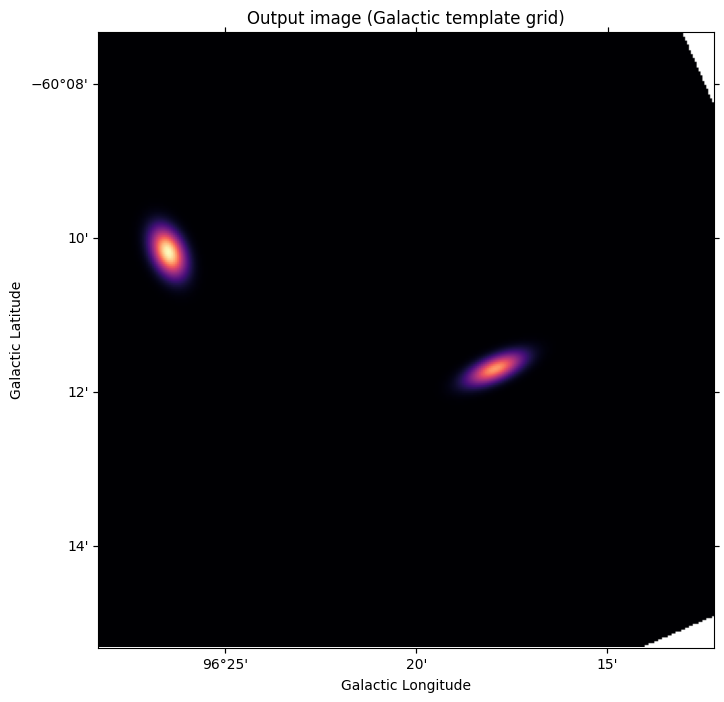

In [25]:
out_wcs_plot = build_wcs_from_xradio(out, dim_a="l", dim_b="m").wcs
out_img_plot = out["SKY"].isel(time=0, frequency=0, polarization=0).values
fig_o, ax_o = generate_astro_plot(out_img_plot, out_wcs_plot)
ax_o.set_title("Output image (Galactic template grid)")
ax_o.coords[0].set_axislabel("Galactic Longitude")
ax_o.coords[1].set_axislabel("Galactic Latitude")


## 7) Validate output coordinate system matches template coordinate system

In [34]:
# Build Galactic lon/lat on template grid directly from template WCS.
tmpl_wcs = build_wcs_from_xradio(template_gal, dim_a="l", dim_b="m").wcs
n_l_t = int(template_gal.sizes["l"])
n_m_t = int(template_gal.sizes["m"])
ii_t, jj_t = np.indices((n_l_t, n_m_t)) 
tmpl_glon_deg, tmpl_glat_deg = tmpl_wcs.wcs_pix2world(ii_t, jj_t, 0)
tmpl_glon_rad = np.deg2rad(tmpl_glon_deg)
tmpl_glat_rad = np.deg2rad(tmpl_glat_deg)

print(out["galactic_longitude"].values - tmpl_glon_rad )

glon_equal = np.allclose(
    out["galactic_longitude"].values,
    tmpl_glon_rad,
    rtol=0.0,
    atol=1e-14,
)
glat_equal = np.allclose(
    out["galactic_latitude"].values,
    tmpl_glat_rad,
    rtol=0.0,
    atol=1e-14,
)
print("galactic_longitude grids identical:", bool(glon_equal))
print("galactic_latitude grids identical:", bool(glat_equal))
print(
    "largest abs diff in longitude",
    np.max(
        np.abs(
            out["galactic_longitude"].values - tmpl_glon_rad
        )
    ), "rad"
)

print(
    "largest abs diff in latitude",
    np.max(
        np.abs(
            out["galactic_latitude"].values - tmpl_glat_rad
        )
    ), "rad"
)


assert glon_equal and glat_equal

[[-6.66133815e-16  0.00000000e+00  0.00000000e+00 ...  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00 ...  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00 ...  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 ...
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00 ...  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00 ...  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00 ...  0.00000000e+00
   0.00000000e+00  0.00000000e+00]]
galactic_longitude grids identical: True
galactic_latitude grids identical: True
largest abs diff in longitude 1.1102230246251565e-15 rad
largest abs diff in latitude 6.661338147750939e-16 rad


## 8) Peak-world validation in Galactic coordinates

For each input peak:
1. Read FK5 RA/Dec at the input peak.
2. Convert to Galactic with Astropy.
3. Map that Galactic world point to output pixel coordinates.
4. Find nearby output peak and compare Galactic world coordinates.

In [35]:
def peak_in_window(img2d, center_i, center_j, half_width=16):
    i0 = max(int(round(center_i)) - half_width, 0)
    i1 = min(int(round(center_i)) + half_width + 1, img2d.shape[0])
    j0 = max(int(round(center_j)) - half_width, 0)
    j1 = min(int(round(center_j)) + half_width + 1, img2d.shape[1])
    sub = img2d[i0:i1, j0:j1]
    ii, jj = np.unravel_index(np.nanargmax(sub), sub.shape)
    return int(i0 + ii), int(j0 + jj)

input_wcs = build_wcs_from_xradio(input_fk5, dim_a="l", dim_b="m").wcs
out_wcs = build_wcs_from_xradio(out, dim_a="l", dim_b="m").wcs
input_img = input_fk5["SKY"].isel(time=0, frequency=0, polarization=0).values
out_img = out["SKY"].isel(time=0, frequency=0, polarization=0).values

gal_rows = []
for k, (ci, cj, _, _, _) in enumerate(input_components, start=1):
    in_i, in_j = peak_in_window(input_img, ci, cj)
    in_ra_deg, in_dec_deg = input_wcs.wcs_pix2world(float(in_i), float(in_j), 0)

    in_fk5 = SkyCoord(float(in_ra_deg) * u.deg, float(in_dec_deg) * u.deg, frame="fk5")
    in_gal = in_fk5.transform_to("galactic")
    in_glon_deg = float(in_gal.spherical.lon.to_value(u.deg))
    in_glat_deg = float(in_gal.spherical.lat.to_value(u.deg))

    map_i, map_j = out_wcs.wcs_world2pix(in_glon_deg, in_glat_deg, 0)
    map_i = float(np.asarray(map_i).reshape(-1)[0])
    map_j = float(np.asarray(map_j).reshape(-1)[0])
    out_i, out_j = peak_in_window(out_img, map_i, map_j)

    out_glon_deg, out_glat_deg = out_wcs.wcs_pix2world(float(out_i), float(out_j), 0)
    out_glon_deg = float(out_glon_deg)
    out_glat_deg = float(out_glat_deg)

    dlon = np.arctan2(np.sin(np.deg2rad(out_glon_deg - in_glon_deg)), np.cos(np.deg2rad(out_glon_deg - in_glon_deg)))
    dlon *= np.cos(np.deg2rad(0.5 * (out_glat_deg + in_glat_deg)))
    dlat = np.deg2rad(out_glat_deg - in_glat_deg)
    sep_arcsec = float(np.rad2deg(np.hypot(dlon, dlat)) * 3600.0)

    gal_rows.append((
        k,
        (in_i, in_j),
        (out_i, out_j),
        in_glon_deg, in_glat_deg,
        out_glon_deg, out_glat_deg,
        sep_arcsec,
    ))

print("Galactic Peak Comparison")
header = ("src", "input peak", "output peak", "input (l,b) deg", "output (l,b) deg", "sep_arcsec")
rows = []
for r in gal_rows:
    rows.append((
        str(r[0]),
        str(r[1]),
        str(r[2]),
        f"({r[3]:.8f}, {r[4]:.8f})",
        f"({r[5]:.8f}, {r[6]:.8f})",
        f"{r[7]:.4f}",
    ))
widths = [len(h) for h in header]
for row in rows:
    for i, v in enumerate(row):
        widths[i] = max(widths[i], len(v))
def fmt(vals):
    return "| " + " | ".join(vals[i].ljust(widths[i]) for i in range(len(vals))) + " |"
print(fmt(header))
print("| " + " | ".join("-" * w for w in widths) + " |")
for row in rows:
    print(fmt(row))

gal_tol_arcsec = 0.5 * max(input_cell_arcsec, template_cell_arcsec)
max_gal_sep = max(r[7] for r in gal_rows)
print("\nGalactic world-coordinate tolerance (arcsec):", float(gal_tol_arcsec))
print("Max Galactic peak separation (arcsec):", float(max_gal_sep))
assert max_gal_sep <= gal_tol_arcsec


Galactic Peak Comparison
| src | input peak | output peak | input (l,b) deg             | output (l,b) deg            | sep_arcsec |
| --- | ---------- | ----------- | --------------------------- | --------------------------- | ---------- |
| 1   | (112, 204) | (36, 205)   | (96.44108454, -60.16992191) | (96.44113649, -60.16976110) | 0.5863     |
| 2   | (206, 116) | (206, 144)  | (96.29883235, -60.19519288) | (96.29870849, -60.19521280) | 0.2329     |

Galactic world-coordinate tolerance (arcsec): 1.0499999999999998
Max Galactic peak separation (arcsec): 0.5863376458924657


## 9) Validate output includes FK5 coordinates and preserves FK5 peak positions

Because `include_original_world_coords=True` was passed to `reproject_to_match`,
the output now carries FK5-equivalent coordinates on the Galactic output grid:
- `original_right_ascension`
- `original_declination`

We compare FK5 coordinates at each input peak against FK5 coordinates sampled
at the corresponding output peak and verify that separations are within tolerance.

In [ ]:
# Confirm expected output coordinates were added by reproject_to_match.
assert "original_right_ascension" in out.coords
assert "original_declination" in out.coords

# Compare FK5 at each input peak vs FK5 sampled at corresponding output peak.
input_wcs = build_wcs_from_xradio(input_fk5, dim_a="l", dim_b="m").wcs
out_wcs = build_wcs_from_xradio(out, dim_a="l", dim_b="m").wcs
input_img = input_fk5["SKY"].isel(time=0, frequency=0, polarization=0).values
out_img = out["SKY"].isel(time=0, frequency=0, polarization=0).values

radec_rows = []
for k, (ci, cj, _, _, _) in enumerate(input_components, start=1):
    # 1) Locate the actual input peak near expected Gaussian center.
    in_i, in_j = peak_in_window(input_img, ci, cj)
    in_ra_deg, in_dec_deg = input_wcs.wcs_pix2world(float(in_i), float(in_j), 0)

    # 2) Convert FK5 peak world coordinate to Galactic, then map to output pixels.
    in_fk5 = SkyCoord(float(in_ra_deg) * u.deg, float(in_dec_deg) * u.deg, frame="fk5")
    in_gal = in_fk5.transform_to("galactic")
    in_glon_deg = float(in_gal.spherical.lon.to_value(u.deg))
    in_glat_deg = float(in_gal.spherical.lat.to_value(u.deg))

    map_i, map_j = out_wcs.wcs_world2pix(in_glon_deg, in_glat_deg, 0)
    map_i = float(np.asarray(map_i).reshape(-1)[0])
    map_j = float(np.asarray(map_j).reshape(-1)[0])

    # 3) Find nearest output peak and read output-stored FK5 coords there.
    out_i, out_j = peak_in_window(out_img, map_i, map_j)
    out_ra_deg = float(np.rad2deg(out["original_right_ascension"].values[out_i, out_j]))
    out_dec_deg = float(np.rad2deg(out["original_declination"].values[out_i, out_j]))

    # 4) Compute spherical small-angle separation in arcsec.
    d_ra = np.arctan2(np.sin(np.deg2rad(out_ra_deg - float(in_ra_deg))), np.cos(np.deg2rad(out_ra_deg - float(in_ra_deg))))
    d_ra *= np.cos(np.deg2rad(0.5 * (out_dec_deg + float(in_dec_deg))))
    d_dec = np.deg2rad(out_dec_deg - float(in_dec_deg))
    sep_arcsec = float(np.rad2deg(np.hypot(d_ra, d_dec)) * 3600.0)

    radec_rows.append((
        int(k),
        (int(in_i), int(in_j)),
        (int(out_i), int(out_j)),
        float(in_ra_deg), float(in_dec_deg),
        float(out_ra_deg), float(out_dec_deg),
        float(sep_arcsec),
    ))

print("FK5 Peak Comparison (Input vs Output original_* coordinates)")
header = ("src", "input peak", "output peak", "input (RA,Dec) deg", "output (RA,Dec) deg", "sep_arcsec")
rows = []
for r in radec_rows:
    rows.append((
        str(r[0]),
        str(r[1]),
        str(r[2]),
        f"({r[3]:.8f}, {r[4]:.8f})",
        f"({r[5]:.8f}, {r[6]:.8f})",
        f"{r[7]:.4f}",
    ))
widths = [len(h) for h in header]
for row in rows:
    for i, v in enumerate(row):
        widths[i] = max(widths[i], len(v))
def fmt(vals):
    return "| " + " | ".join(vals[i].ljust(widths[i]) for i in range(len(vals))) + " |"
print(fmt(header))
print("| " + " | ".join("-" * w for w in widths) + " |")
for row in rows:
    print(fmt(row))

radec_tol_arcsec = 0.5 * max(input_cell_arcsec, template_cell_arcsec)
max_radec_sep = max(r[7] for r in radec_rows)
print("\nRA/Dec tolerance (arcsec):", float(radec_tol_arcsec))
print("Max RA/Dec peak separation (arcsec):", float(max_radec_sep))
assert max_radec_sep <= radec_tol_arcsec